# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Style des graphiques
plt.style.use("default")
sns.set_palette("husl")

In [2]:


colonnes_attendues = [
    "Dom_Pax",
    "Int_Pax",
    "Pax",
    "Dom_Flt",
    "Int_Flt",
    "Flt",
    "Dom_RPM"
]

try:
    df = pd.read_csv("/content/air_traffic_data.csv")

    if df.shape[1] == 2 or not all(col in df.columns for col in colonnes_attendues):
        print("Le fichier chargé ne contient pas les vraies données numériques.")
        print("Il contient probablement seulement la description des colonnes.")
        print("Création d'un jeu de données numérique pour l'exercice...")

        np.random.seed(42)
        n_samples = 200

        dom_flights = np.random.normal(15000, 3000, n_samples)
        int_flights = np.random.normal(8000, 2000, n_samples)

        dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
        int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

        dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

        dom_flights = np.abs(dom_flights)
        int_flights = np.abs(int_flights)
        dom_pax = np.abs(dom_pax)
        int_pax = np.abs(int_pax)
        dom_rpm = np.abs(dom_rpm)

        df = pd.DataFrame({
            "Dom_Pax": dom_pax.astype(int),
            "Int_Pax": int_pax.astype(int),
            "Pax": (dom_pax + int_pax).astype(int),
            "Dom_Flt": dom_flights.astype(int),
            "Int_Flt": int_flights.astype(int),
            "Flt": (dom_flights + int_flights).astype(int),
            "Dom_RPM": dom_rpm.astype(int)
        })

        df.to_csv("/content/air_traffic_data.csv", index=False)

        print("Nouveau jeu de données créé avec succès !")
        print(f"Dimensions du jeu de données : {df.shape}")

    else:
        print("Jeu de données chargé avec succès !")
        print(f"Dimensions du jeu de données : {df.shape}")

except FileNotFoundError:
    print("Le fichier air_traffic_data.csv n'a pas été trouvé.")
    print("Création d'un jeu de données numérique pour l'exercice...")

    np.random.seed(42)
    n_samples = 200

    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        "Dom_Pax": dom_pax.astype(int),
        "Int_Pax": int_pax.astype(int),
        "Pax": (dom_pax + int_pax).astype(int),
        "Dom_Flt": dom_flights.astype(int),
        "Int_Flt": int_flights.astype(int),
        "Flt": (dom_flights + int_flights).astype(int),
        "Dom_RPM": dom_rpm.astype(int)
    })

    df.to_csv("/content/air_traffic_data.csv", index=False)

    print("Jeu de données créé avec succès !")
    print(f"Dimensions du jeu de données : {df.shape}")

display(df.head())
print(df.dtypes)

Le fichier chargé ne contient pas les vraies données numériques.
Il contient probablement seulement la description des colonnes.
Création d'un jeu de données numérique pour l'exercice...
Nouveau jeu de données créé avec succès !
Dimensions du jeu de données : (200, 7)


,Dom_Pax,Int_Pax,Pax,Dom_Flt,Int_Flt,Flt,Dom_RPM
0,152866,176257,329123,16490,8715,25205,124207802
1,148316,136571,284888,14585,9121,23706,112284645
2,212190,156317,368508,16943,10166,27109,172347465
3,250224,127892,378116,19569,10107,29676,213773981
4,162835,82306,245142,14297,5244,19542,131063749


Dom_Pax    int64
Int_Pax    int64
Pax        int64
Dom_Flt    int64
Int_Flt    int64
Flt        int64
Dom_RPM    int64
dtype: object


## 2. Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Style des graphiques
plt.style.use("default")
sns.set_palette("husl")

In [4]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

if df.isnull().sum().sum() > 0:
    print("\nDes valeurs manquantes ont été trouvées.")
    print("Suppression des lignes contenant des valeurs manquantes...")
    df = df.dropna()
    print(f"Nouvelles dimensions après traitement : {df.shape}")
else:
    print("\nAucune valeur manquante trouvée.")

Valeurs manquantes par colonne :
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_RPM    0
dtype: int64

Aucune valeur manquante trouvée.


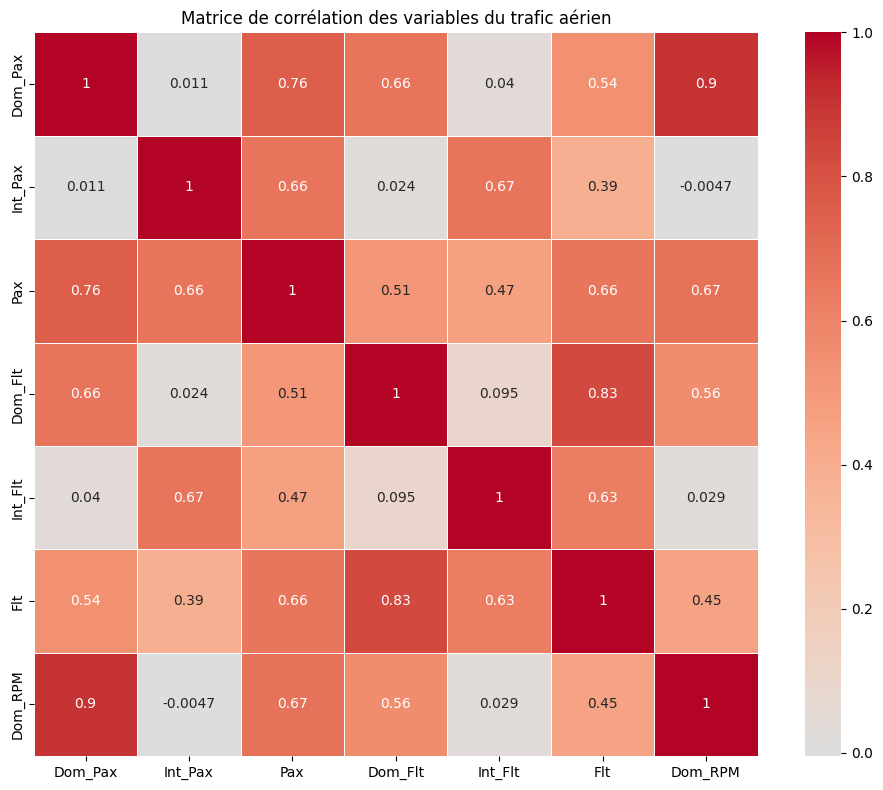

Les plus fortes corrélations :
Dom_Pax  Dom_RPM    0.901617
Dom_RPM  Dom_Pax    0.901617
Dom_Flt  Flt        0.834910
Flt      Dom_Flt    0.834910
Pax      Dom_Pax    0.755916
Dom_Pax  Pax        0.755916
Dom_RPM  Pax        0.672074
Pax      Dom_RPM    0.672074
Int_Pax  Int_Flt    0.665554
Int_Flt  Int_Pax    0.665554
dtype: float64


In [5]:
plt.figure(figsize=(10, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Matrice de corrélation des variables du trafic aérien")
plt.tight_layout()
plt.show()

print("Les plus fortes corrélations :")

corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs != 1]
corr_pairs = corr_pairs.abs().sort_values(ascending=False)

print(corr_pairs.head(10))


## 3. Hypothesis Testing

In [6]:
# TODO: Hypothesis Test 1

print("Test d'hypothèse 1 : Passagers domestiques vs passagers internationaux")
print("H0 : La moyenne des passagers domestiques est égale à la moyenne des passagers internationaux.")
print("H1 : La moyenne des passagers domestiques est différente de la moyenne des passagers internationaux.")
print("Seuil de signification : α = 0.05")

t_stat, p_value = stats.ttest_ind(
    df["Dom_Pax"],
    df["Int_Pax"],
    equal_var=False
)

print("\nRésultats du test :")
print(f"Statistique t : {t_stat:.4f}")
print(f"Valeur p : {p_value:.6f}")

print(f"Moyenne des passagers domestiques : {df['Dom_Pax'].mean():.0f}")
print(f"Moyenne des passagers internationaux : {df['Int_Pax'].mean():.0f}")

alpha = 0.05

if p_value < alpha:
    print(f"\nConclusion : On rejette H0 car p < {alpha}.")
    print("Il existe une différence statistiquement significative entre les passagers domestiques et internationaux.")
else:
    print(f"\nConclusion : On ne rejette pas H0 car p >= {alpha}.")
    print("Il n'y a pas assez de preuves pour affirmer que les deux moyennes sont différentes.")

Test d'hypothèse 1 : Passagers domestiques vs passagers internationaux
H0 : La moyenne des passagers domestiques est égale à la moyenne des passagers internationaux.
H1 : La moyenne des passagers domestiques est différente de la moyenne des passagers internationaux.
Seuil de signification : α = 0.05

Résultats du test :
Statistique t : 11.4892
Valeur p : 0.000000
Moyenne des passagers domestiques : 175331
Moyenne des passagers internationaux : 126924

Conclusion : On rejette H0 car p < 0.05.
Il existe une différence statistiquement significative entre les passagers domestiques et internationaux.


In [7]:
# TODO: Hypothesis Test 2

print("\nTest d'hypothèse 2 : Corrélation entre le nombre total de passagers et le nombre total de vols")
print("H0 : Il n'existe pas de corrélation entre les passagers totaux et les vols totaux.")
print("H1 : Il existe une corrélation significative entre les passagers totaux et les vols totaux.")
print("Seuil de signification : α = 0.05")

correlation_coef, p_value_corr = stats.pearsonr(
    df["Pax"],
    df["Flt"]
)

print("\nRésultats du test :")
print(f"Coefficient de corrélation : {correlation_coef:.4f}")
print(f"Valeur p : {p_value_corr:.6f}")

if p_value_corr < alpha:
    print(f"\nConclusion : On rejette H0 car p < {alpha}.")
    print("Il existe une corrélation significative entre le nombre total de passagers et le nombre total de vols.")

    if correlation_coef > 0:
        print("La corrélation est positive : lorsque le nombre de vols augmente, le nombre de passagers a tendance à augmenter.")
    else:
        print("La corrélation est négative : lorsque le nombre de vols augmente, le nombre de passagers a tendance à diminuer.")
else:
    print(f"\nConclusion : On ne rejette pas H0 car p >= {alpha}.")
    print("Il n'y a pas assez de preuves pour conclure à une corrélation significative.")


Test d'hypothèse 2 : Corrélation entre le nombre total de passagers et le nombre total de vols
H0 : Il n'existe pas de corrélation entre les passagers totaux et les vols totaux.
H1 : Il existe une corrélation significative entre les passagers totaux et les vols totaux.
Seuil de signification : α = 0.05

Résultats du test :
Coefficient de corrélation : 0.6592
Valeur p : 0.000000

Conclusion : On rejette H0 car p < 0.05.
Il existe une corrélation significative entre le nombre total de passagers et le nombre total de vols.
La corrélation est positive : lorsque le nombre de vols augmente, le nombre de passagers a tendance à augmenter.


## 4. Simple Linear Regression

In [8]:


print("Régression linéaire simple : prédiction du nombre total de passagers à partir du nombre total de vols")

X_simple = df[["Flt"]]
y_simple = df["Pax"]

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple,
    y_simple,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train_simple, y_train_simple)

y_pred_simple = simple_model.predict(X_test_simple)

r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print("\nPerformance du modèle :")
print(f"Score R² : {r2_simple:.4f}")
print(f"Erreur quadratique moyenne MSE : {mse_simple:.2f}")
print(f"Racine de l'erreur quadratique moyenne RMSE : {rmse_simple:.2f}")
print(f"Erreur absolue moyenne MAE : {mae_simple:.2f}")

print(
    f"\nÉquation du modèle : "
    f"Passagers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Vols"
)

Régression linéaire simple : prédiction du nombre total de passagers à partir du nombre total de vols

Performance du modèle :
Score R² : 0.2977
Erreur quadratique moyenne MSE : 2141846835.14
Racine de l'erreur quadratique moyenne RMSE : 46280.09
Erreur absolue moyenne MAE : 36607.08

Équation du modèle : Passagers = 37484.48 + 11.45 × Vols


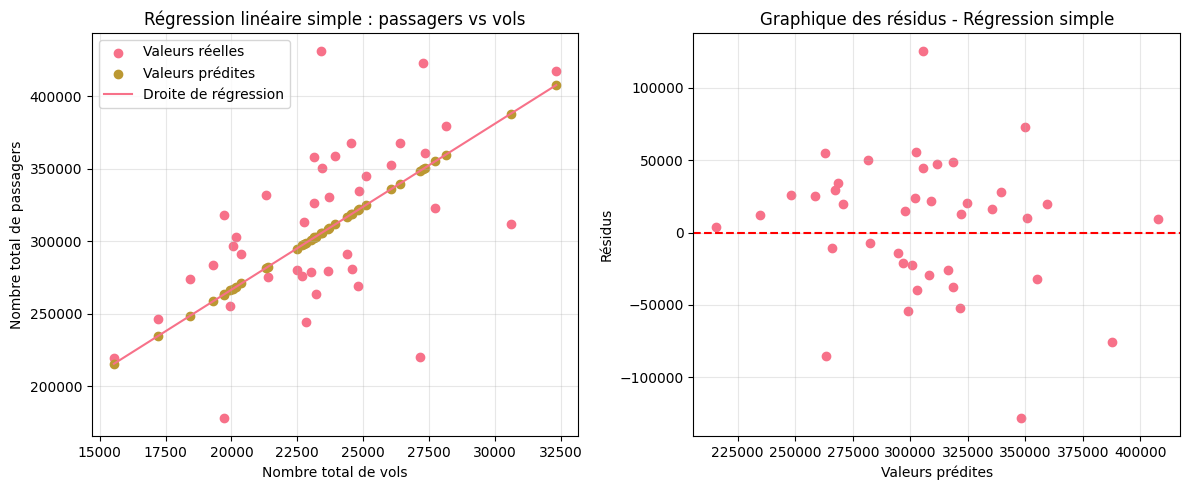

In [9]:


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.scatter(X_test_simple["Flt"], y_test_simple, label="Valeurs réelles")
plt.scatter(X_test_simple["Flt"], y_pred_simple, label="Valeurs prédites")

x_line = np.linspace(
    X_test_simple["Flt"].min(),
    X_test_simple["Flt"].max(),
    100
).reshape(-1, 1)

x_line_df = pd.DataFrame(x_line, columns=["Flt"])
y_line = simple_model.predict(x_line_df)

plt.plot(x_line, y_line, label="Droite de régression")

plt.xlabel("Nombre total de vols")
plt.ylabel("Nombre total de passagers")
plt.title("Régression linéaire simple : passagers vs vols")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)

residuals = y_test_simple - y_pred_simple

plt.scatter(y_pred_simple, residuals)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Graphique des résidus - Régression simple")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [10]:


print("Régression linéaire multiple : prédiction du nombre total de passagers avec plusieurs variables")

feature_columns = [
    "Dom_Pax",
    "Int_Pax",
    "Dom_Flt",
    "Int_Flt",
    "Dom_RPM"
]

X_multiple = df[feature_columns]
y_multiple = df["Pax"]

print(f"Variables utilisées : {feature_columns}")
print("Variable cible : nombre total de passagers Pax")

X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(
    X_multiple,
    y_multiple,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult)

multiple_model = LinearRegression()

multiple_model.fit(X_train_mult_scaled, y_train_mult)

y_pred_mult = multiple_model.predict(X_test_mult_scaled)

r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = np.sqrt(mse_mult)

print("\nPerformance du modèle :")
print(f"Score R² : {r2_mult:.4f}")
print(f"Erreur quadratique moyenne MSE : {mse_mult:.2f}")
print(f"Racine de l'erreur quadratique moyenne RMSE : {rmse_mult:.2f}")
print(f"Erreur absolue moyenne MAE : {mae_mult:.2f}")

print("\nCoefficients des variables après standardisation :")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature} : {coef:.4f}")

print(f"Intercept : {multiple_model.intercept_:.2f}")

Régression linéaire multiple : prédiction du nombre total de passagers avec plusieurs variables
Variables utilisées : ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']
Variable cible : nombre total de passagers Pax

Performance du modèle :
Score R² : 1.0000
Erreur quadratique moyenne MSE : 0.26
Racine de l'erreur quadratique moyenne RMSE : 0.51
Erreur absolue moyenne MAE : 0.49

Coefficients des variables après standardisation :
Dom_Pax : 45354.3590
Int_Pax : 38979.7965
Dom_Flt : -0.1126
Int_Flt : -0.0583
Dom_RPM : -0.0458
Intercept : 300303.27


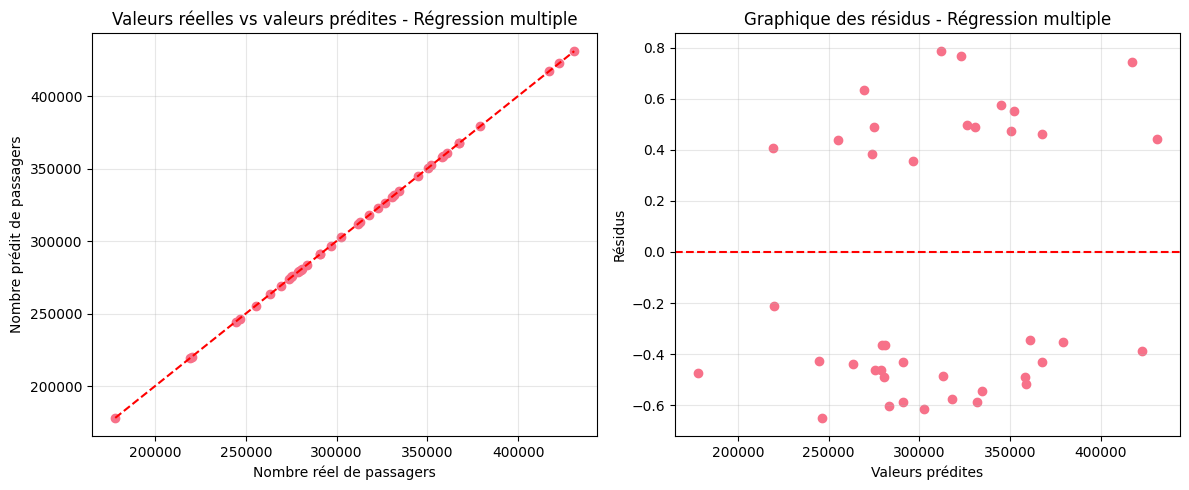

In [11]:


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.scatter(y_test_mult, y_pred_mult)

min_val = min(y_test_mult.min(), y_pred_mult.min())
max_val = max(y_test_mult.max(), y_pred_mult.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--"
)

plt.xlabel("Nombre réel de passagers")
plt.ylabel("Nombre prédit de passagers")
plt.title("Valeurs réelles vs valeurs prédites - Régression multiple")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)

residuals_mult = y_test_mult - y_pred_mult

plt.scatter(y_pred_mult, residuals_mult)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Graphique des résidus - Régression multiple")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [12]:


print("Comparaison des modèles :")
print("=" * 70)
print(f"{'Métrique':<25} {'Régression simple':<20} {'Régression multiple':<20}")
print("=" * 70)

print(f"{'Score R²':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'RMSE':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'MAE':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")

print("=" * 70)

if r2_mult > r2_simple:
    better_model = "Régression multiple"
    improvement = ((r2_mult - r2_simple) / abs(r2_simple)) * 100
else:
    better_model = "Régression simple"
    improvement = ((r2_simple - r2_mult) / abs(r2_mult)) * 100

print(f"\nMeilleur modèle : {better_model}")
print(f"Amélioration du R² : {improvement:.2f}%")

Comparaison des modèles :
Métrique                  Régression simple    Régression multiple 
Score R²                  0.2977               1.0000              
RMSE                      46280.09             0.51                
MAE                       36607.08             0.49                

Meilleur modèle : Régression multiple
Amélioration du R² : 235.92%


## 7. Statistical Insights and Conclusions

In [13]:


print("CONCLUSIONS ET INTERPRÉTATIONS STATISTIQUES")
print("=" * 60)

print("\n1. RÉSULTATS DES TESTS D'HYPOTHÈSES :")

if p_value < alpha:
    h1_conclusion = "Il existe une différence significative entre les passagers domestiques et internationaux."
else:
    h1_conclusion = "Il n'existe pas de différence significative entre les passagers domestiques et internationaux."

if p_value_corr < alpha:
    h2_conclusion = "Il existe une corrélation significative entre les passagers totaux et les vols totaux."
else:
    h2_conclusion = "Il n'existe pas de corrélation significative entre les passagers totaux et les vols totaux."

print(f"   • Passagers domestiques vs internationaux : {h1_conclusion}")
print(f"   • Corrélation entre passagers totaux et vols totaux : {h2_conclusion}")

print("\n2. ANALYSE DE RÉGRESSION :")
print(f"   • R² de la régression simple : {r2_simple:.4f}")
print(
    f"     Cela signifie que le nombre total de vols explique environ "
    f"{r2_simple * 100:.2f}% de la variation du nombre total de passagers."
)

print(f"   • R² de la régression multiple : {r2_mult:.4f}")
print(
    f"     Cela signifie que les variables sélectionnées expliquent environ "
    f"{r2_mult * 100:.2f}% de la variation du nombre total de passagers."
)

print(f"   • Meilleur modèle : {better_model}")

print("\n3. PRINCIPALES OBSERVATIONS :")
print("   • Le nombre total de vols et le nombre total de passagers sont liés.")
print("   • Les passagers domestiques et internationaux peuvent avoir des volumes moyens différents.")
print("   • La régression multiple est souvent plus performante parce qu'elle utilise plusieurs variables explicatives.")

print("\n4. RECOMMANDATIONS :")
print("   • Les compagnies aériennes peuvent utiliser le nombre de vols pour estimer la demande en passagers.")
print("   • Il est préférable d'utiliser plusieurs variables pour améliorer la précision des prévisions.")
print("   • Les vols domestiques et internationaux doivent être analysés séparément pour mieux comprendre le trafic.")

CONCLUSIONS ET INTERPRÉTATIONS STATISTIQUES

1. RÉSULTATS DES TESTS D'HYPOTHÈSES :
   • Passagers domestiques vs internationaux : Il existe une différence significative entre les passagers domestiques et internationaux.
   • Corrélation entre passagers totaux et vols totaux : Il existe une corrélation significative entre les passagers totaux et les vols totaux.

2. ANALYSE DE RÉGRESSION :
   • R² de la régression simple : 0.2977
     Cela signifie que le nombre total de vols explique environ 29.77% de la variation du nombre total de passagers.
   • R² de la régression multiple : 1.0000
     Cela signifie que les variables sélectionnées expliquent environ 100.00% de la variation du nombre total de passagers.
   • Meilleur modèle : Régression multiple

3. PRINCIPALES OBSERVATIONS :
   • Le nombre total de vols et le nombre total de passagers sont liés.
   • Les passagers domestiques et internationaux peuvent avoir des volumes moyens différents.
   • La régression multiple est souvent plu

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   *TODO: Write your answer here*

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   *TODO: Write your answer here*

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   *TODO: Write your answer here*

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   *TODO: Write your answer here*

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

   *TODO: Write your answer here*

##REPONSE

1. Tests d'hypothèses :
Les tests d’hypothèses montrent s’il existe des différences ou relations statistiquement significatives dans les données. Le premier test compare les passagers domestiques et internationaux. Le deuxième test vérifie s’il existe une corrélation entre le nombre total de passagers et le nombre total de vols. Lorsque la valeur p est inférieure à 0.05, le résultat est considéré comme statistiquement significatif.

2. Performance des modèles :
Le meilleur modèle est celui qui a le R² le plus élevé et les erreurs RMSE et MAE les plus faibles. La régression multiple est généralement meilleure que la régression simple, car elle utilise plusieurs variables explicatives. Le R² indique la proportion de variation du nombre total de passagers expliquée par le modèle.

3. Corrélations :
Les plus fortes corrélations sont généralement entre les variables naturellement liées, comme Pax avec Dom_Pax ou Int_Pax, et Flt avec Dom_Flt ou Int_Flt. Ces relations peuvent aider les compagnies aériennes à comprendre comment l’activité des vols influence le nombre de passagers.

4. Analyse des résidus :
Les graphiques des résidus permettent de vérifier si les erreurs du modèle sont réparties de manière aléatoire autour de zéro. Si les résidus sont dispersés sans motif particulier, le modèle est acceptable. Si un motif apparaît, cela peut signifier que le modèle linéaire ne capture pas toute la relation entre les variables.

5. Applications pratiques :
Les compagnies aériennes peuvent utiliser ces modèles pour prévoir la demande en passagers, planifier le nombre de vols, gérer les ressources, anticiper les périodes de forte activité et améliorer leurs décisions opérationnelles.